In [1]:
import os
from pathlib import Path

import polars as pl
import pandas as pd
import numpy as np

from mllabs.processor import PolarsLoader, PandasConverter, ExprProcessor
from mllabs import Experimenter, Connector
from mllabs.collector import MetricCollector, ModelAttrCollector

from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score

import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

2026-04-17 06:31:50.505593: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
data_path = Path('data')

loader = make_pipeline(
    PolarsLoader(predefined_types={'id': pl.Int64}),
    PandasConverter(index_col = 'id')
)
df_train = loader.fit_transform([data_path / 'train.csv'])
df_test = loader.transform([data_path / 'test.csv'])
df_org = loader.transform([data_path / 'irrigation_prediction.csv'])
df_org = df_org.set_index(pd.Index(-np.arange(1, len(df_org) + 1), name = 'id'))

y = 'Irrigation_Need'
X_cat = ['Crop_Growth_Stage', 'Crop_Type', 'Irrigation_Type', 'Mulching_Used', 'Region', 'Season', 'Soil_Type', 'Water_Source']
X_num = ['Electrical_Conductivity', 'Field_Area_hectare', 'Humidity', 'Organic_Carbon', 'Previous_Irrigation_mm', 'Rainfall_mm', 
         'Soil_Moisture', 'Soil_pH', 'Sunlight_Hours', 'Temperature_C','Wind_Speed_kmh']
X_all = X_num + X_cat

# Oridinal 변수, 정도에 따른 수치화
df_train[y] = df_train[y].map({'Low': 0, 'Medium': 1, 'High': 2}).astype('int')
df_org[y] = df_org[y].map({'Low': 0, 'Medium': 1, 'High': 2}).astype('int')

## 입력 데이터에 Train과 Test의 차이 확인

In [3]:
df_train.shape, df_test.shape

((630000, 20), (270000, 19))

In [4]:
df_diff = pd.concat([
    df_train.drop(columns=y).assign(is_train = True),
    df_test.assign(is_train = False),
])

In [5]:
if not os.path.exists('exp/diff'):
    e_diff = Experimenter.create(df_diff, 'exp/diff')
    e_diff.set_grp('clf', method = 'predict_proba', role = 'head', edges = {'y': [(None, 'is_train')]})
    e_diff.add_collector(
        MetricCollector(
            'AUC', Connector(edges = {'y': [(None, 'is_train')]}, role = 'head'), slice(-1, None), roc_auc_score, include_train = True
        )
    )
    e_diff.set_node('lgb', grp='clf', processor=lgb.LGBMClassifier, edges={'X': [(None, X_all)]}, params={'verbose': -1})
    e_diff.exp(finalize=True)
else:
    e_diff = Experimenter.load('exp/diff', df_diff)
e_diff.get_collector('AUC').get_metrics_agg()[0]

Loaded: 1 node(s), 1 group(s), 1 fold(s)


,test,train
lgb,0.498932,0.576174


- Train과 Test를 분류하기 어려움 => 분포의 차이는 없음. 

- Test의 분포를 따로 비교할 필요는 보이지 않음

In [6]:
df_train[X_all].value_counts().max()

np.int64(1)

In [7]:
df_diff.drop_duplicates().shape

(900000, 20)

- train 내에서도, 중복된 입력 test와도 중복된 입력을 미존재

In [8]:
del df_diff

## Org와 Train과의 분포 차이 확인

In [9]:
df_diff = pd.concat([
    df_train.assign(is_org = False),
    df_org.assign(is_org = True),
])

In [10]:
df_diff['is_org'].value_counts()

is_org
False    630000
True      10000
Name: count, dtype: int64

In [11]:
if not os.path.exists('exp/diff_org'):
    e_diff = Experimenter.create(df_diff, 'exp/diff_org')
    e_diff.set_grp('clf', method = 'predict_proba', role = 'head', edges = {'y': [(None, 'is_org')]})
    e_diff.add_collector(
        MetricCollector(
            'AUC', Connector(edges = {'y': [(None, 'is_org')]}, role = 'head'), slice(-1, None), roc_auc_score, include_train = True
        )
    )
    e_diff.add_collector(
        ModelAttrCollector('feat_imp', Connector(processor=lgb.LGBMClassifier), result_key = 'feature_importances')
    )
    e_diff.set_node('lgb', grp='clf', processor=lgb.LGBMClassifier, edges={'X': [(None, X_all + [y])]}, params={'verbose': -1})
    e_diff.exp(finalize = True)
else:
    e_diff = Experimenter.load('exp/diff_org', df_diff)
e_diff.get_collector('AUC').get_metrics_agg()[0]

Loaded: 1 node(s), 1 group(s), 1 fold(s)


,test,train
lgb,0.707292,0.800814


In [12]:
e_diff.get_collector('feat_imp').get_attrs_agg('lgb').sort_values(ascending = False)

Previous_Irrigation_mm     373.0
Rainfall_mm                347.0
Soil_pH                    284.0
Humidity                   253.0
Electrical_Conductivity    250.0
Soil_Moisture              246.0
Temperature_C              232.0
Organic_Carbon             228.0
Wind_Speed_kmh             219.0
Sunlight_Hours             199.0
Field_Area_hectare         187.0
Irrigation_Need             62.0
Season                      35.0
Crop_Growth_Stage           27.0
Mulching_Used               27.0
Region                       9.0
Irrigation_Type              8.0
Crop_Type                    7.0
Soil_Type                    6.0
Water_Source                 1.0
dtype: float64

## 수치형 변수

In [13]:
df_train[X_num].describe().T.join(
    df_train[X_num].nunique().rename('nunique')
)

,count,mean,std,min,25%,50%,75%,max,nunique
Electrical_Conductivity,630000.0,1.744605,0.952321,0.10,0.930000,1.740000,2.580000,3.500000,341
Field_Area_hectare,630000.0,7.517745,4.218124,0.30,3.880000,7.380000,11.140000,15.000000,1466
Humidity,630000.0,61.563175,19.708153,25.00,45.389999,61.650002,79.120003,94.989998,6475
Organic_Carbon,630000.0,0.922858,0.365808,0.30,0.610000,0.910000,1.220000,1.600000,131
Previous_Irrigation_mm,630000.0,62.318184,34.246941,0.02,33.139999,61.150002,92.690002,119.989998,10110
Rainfall_mm,630000.0,1462.207642,612.989746,0.38,954.570007,1467.159973,2054.280029,2499.689941,19308
Soil_Moisture,630000.0,37.304482,16.377083,8.00,23.340000,37.750000,51.270000,64.989998,5223
Soil_pH,630000.0,6.482497,0.922504,4.80,5.690000,6.440000,7.270000,8.200000,341
Sunlight_Hours,630000.0,7.513382,1.999322,4.00,5.760000,7.580000,9.250000,11.000000,701
Temperature_C,630000.0,26.998171,8.623621,12.00,19.517500,26.959999,34.540001,42.000000,2934


In [14]:
y_labels = df_train[y].unique()
y_labels

array([0, 1, 2])

### 구간화를 통한 target의 분포 확인

- 'mean': 실제로 Low, Medium, High가 정도를 나타내는 지, 아니면 Nominal한 성질이 강한지를 보기 위해, 0, 1, 2의 평균을 시각화
- 0, 1, 2: 

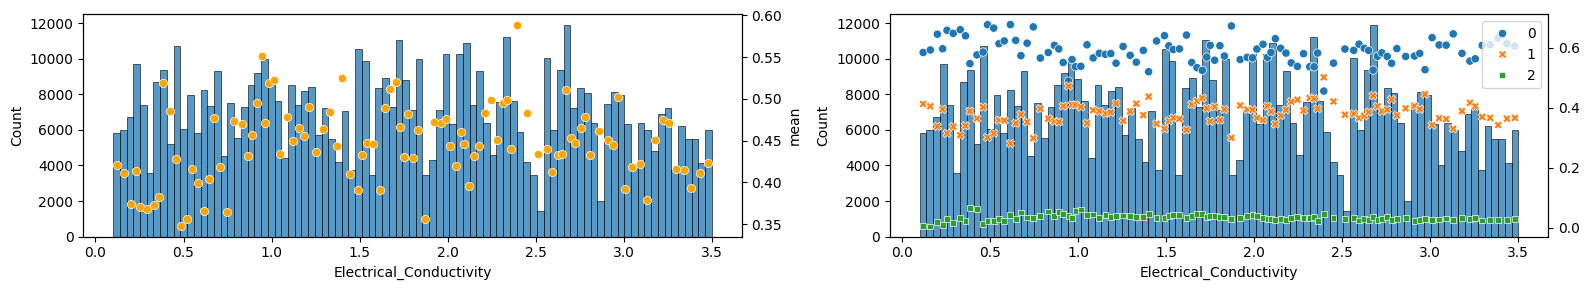

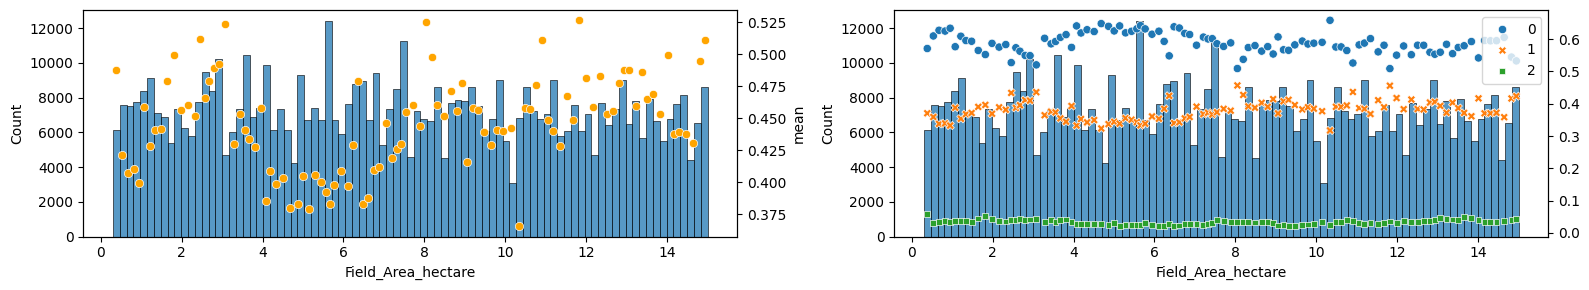

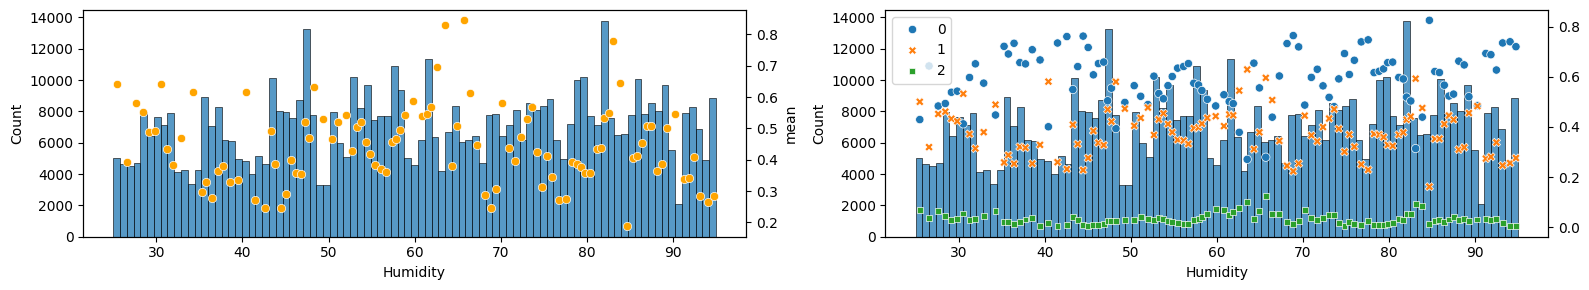

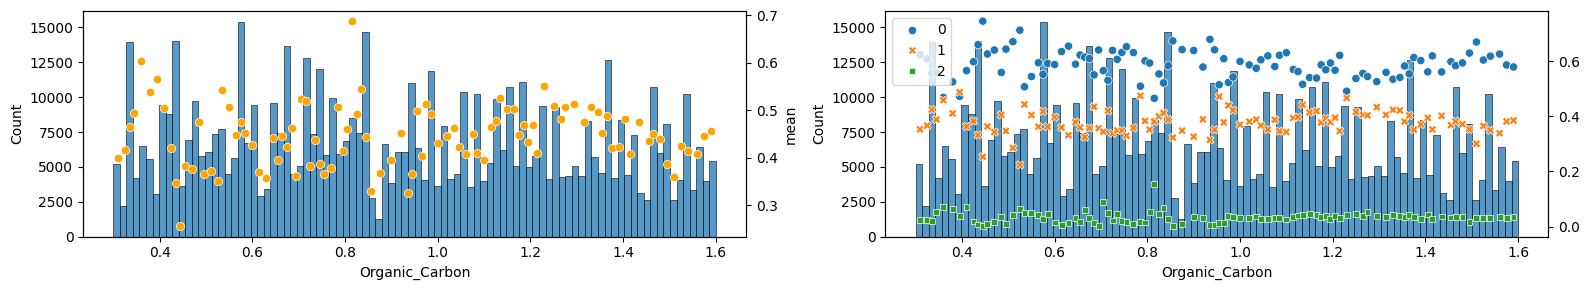

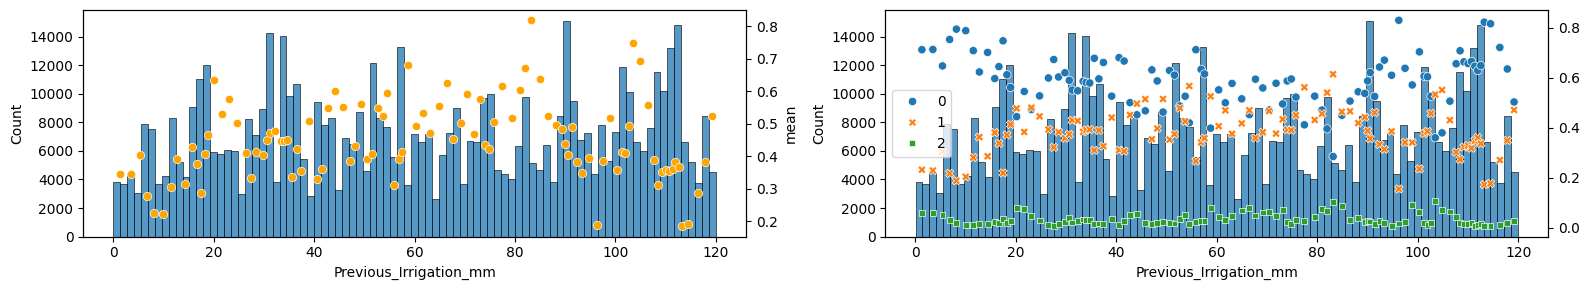

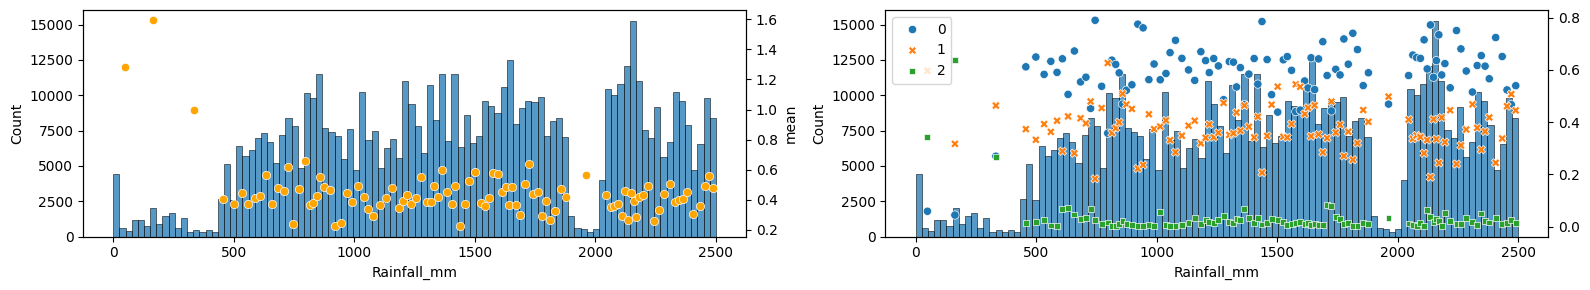

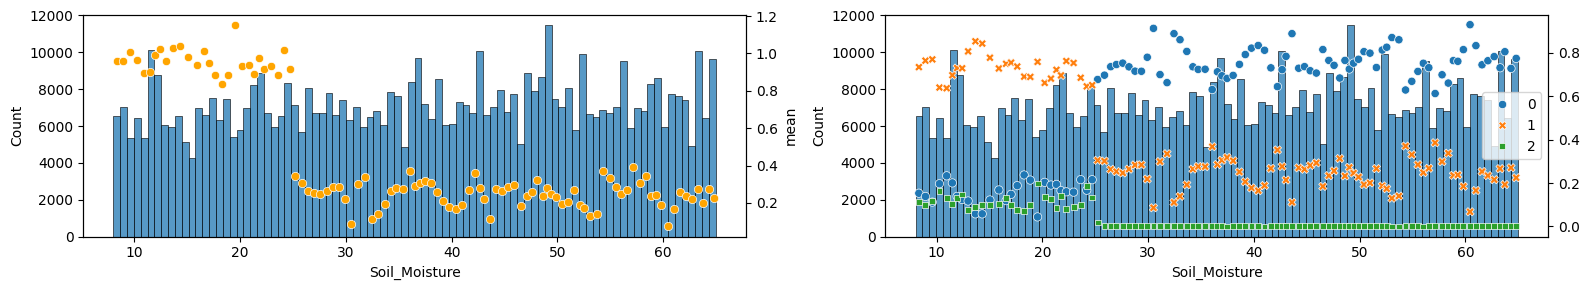

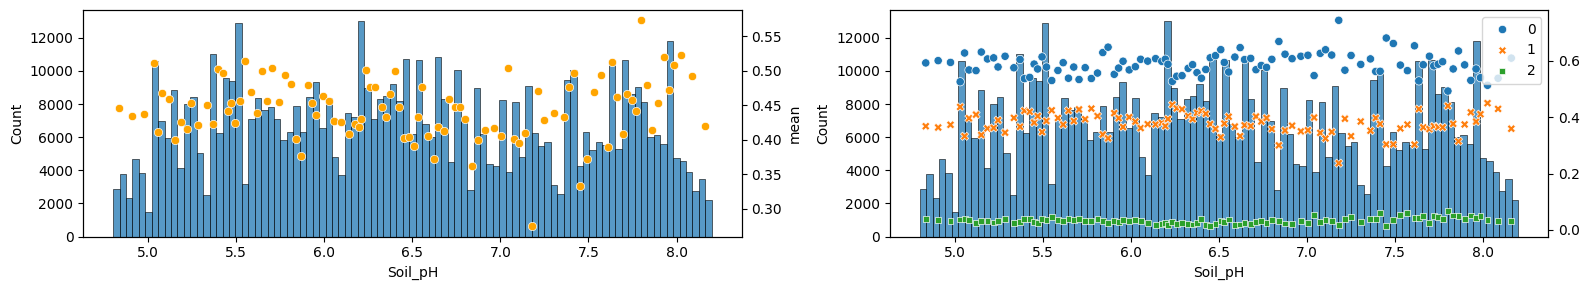

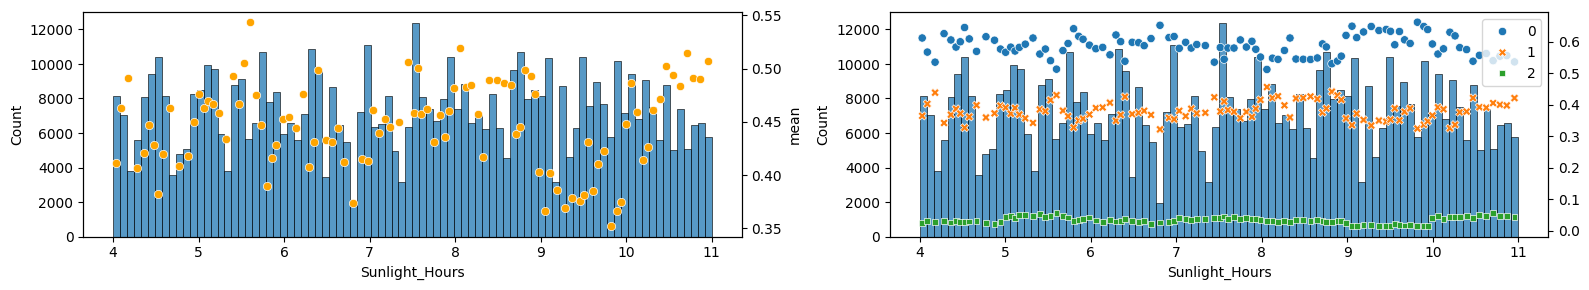

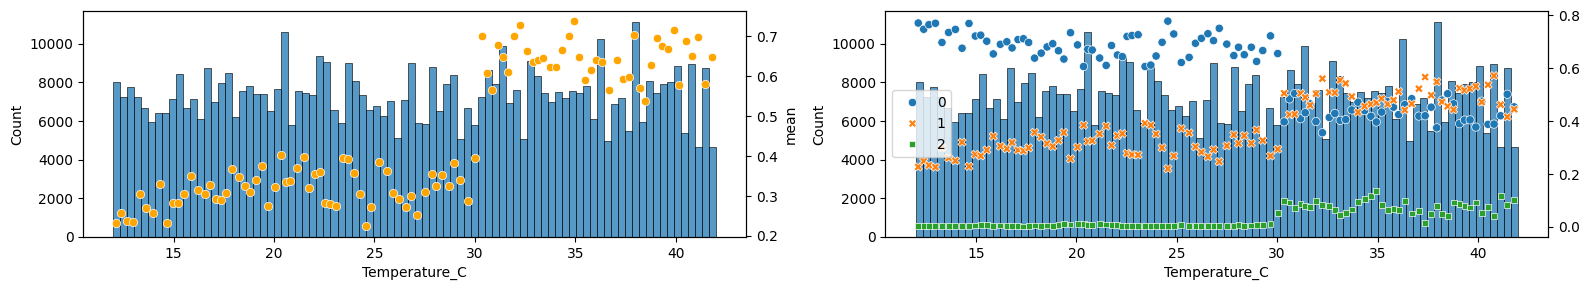

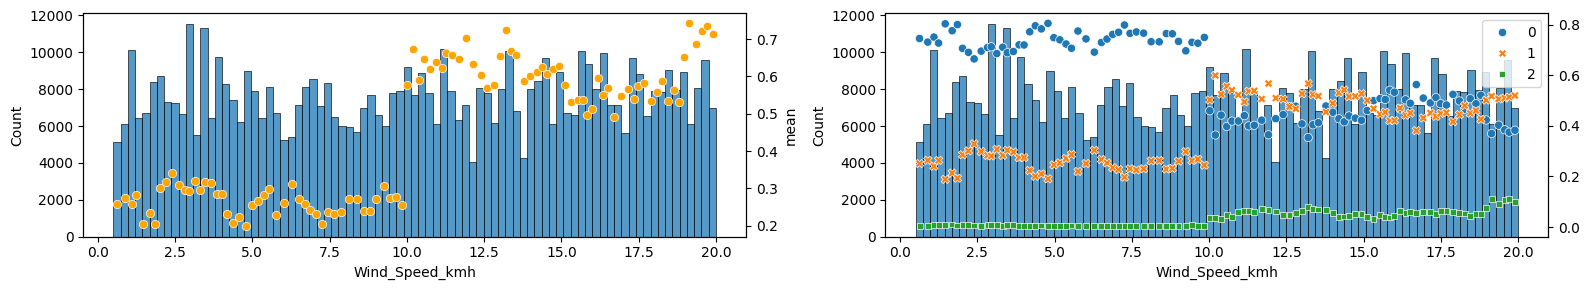

In [16]:
def plot_dist_of_target(v):
    _, axes = plt.subplots(1, 2, figsize=(16, 3))
    sns.histplot(df_train, x = v, ax = axes[0])
    sns.histplot(df_train, x = v, ax = axes[1])
    df_y = df_train.groupby(
        pd.qcut(df_train[v], q = 100, duplicates = 'drop'), observed = True
    )[y].apply(
        lambda x: pd.Series((x.mean(), (x == 0).mean(), (x == 1).mean(), (x == 2).mean()), index  = ['mean', 0, 1, 2])
    ).unstack().pipe(
        lambda x: x.set_index(
            x.index.map(lambda x: (x.left + x.right) / 2).astype('float')
        )
    )
    sns.scatterplot(x = df_y.index, y = df_y['mean'], ax = axes[0].twinx(), color = 'orange')
    sns.scatterplot(df_y[[0, 1, 2]], ax = axes[1].twinx())
    plt.tight_layout()

for i in X_num:
    plot_dist_of_target(i)

- Soil_Moisture, Temperature_C, Wind_speed_kmh 가 높은 상관도를 지니는 것으로 보임

- Soil_Moisture < 25 에서는 0(Low)와 2(High)가 비슷한 비율. 다른 쪽에서는 0(Low)와 1(Medium) 이 비슷

In [17]:
from scipy.stats import pearsonr
pearson_list = list()
for i, j in zip(*np.tril_indices(len(X_num), -1)):
    a, b = X_num[i], X_num[j]
    pearson_list.append(pd.Series([a, b, pearsonr(df_train[a], df_train[b])[0]], index=['var1', 'var2', 'coef']))
df_pearson = pd.DataFrame(pearson_list)
df_pearson.iloc[np.argsort(-df_pearson['coef'].abs())].iloc[:10]

,var1,var2,coef
20,Soil_Moisture,Rainfall_mm,0.044473
42,Temperature_C,Soil_Moisture,-0.037891
50,Wind_Speed_kmh,Rainfall_mm,-0.032776
51,Wind_Speed_kmh,Soil_Moisture,-0.027865
19,Soil_Moisture,Previous_Irrigation_mm,-0.023434
38,Temperature_C,Humidity,-0.020448
8,Previous_Irrigation_mm,Humidity,0.018669
13,Rainfall_mm,Organic_Carbon,-0.017391
41,Temperature_C,Rainfall_mm,-0.016767
17,Soil_Moisture,Humidity,0.015403


## 범주형 변수

In [45]:
df_train[X_cat].apply(lambda x: x.nunique())

Crop_Growth_Stage    4
Crop_Type            6
Irrigation_Type      4
Mulching_Used        2
Region               5
Season               3
Soil_Type            4
Water_Source         4
dtype: int64

### Information Gain

In [35]:
def calc_mi(col):
    return pd.crosstab(
        index = df_train[col], columns = df_train[y], normalize = 'index'
    ).pipe(
        lambda x: (-np.log(x) * x).sum(axis=1)
    ).dot(df_train[col].value_counts(normalize = True))

ent = df_train[y].value_counts(normalize = True).pipe(
    lambda x: -np.log(x).dot(x)
)

In [39]:
(ent - pd.Series({i: calc_mi(i) for i in X_cat})).sort_values(ascending = False)

Crop_Growth_Stage    0.166707
Mulching_Used        0.046896
Water_Source         0.001309
Crop_Type            0.000884
Irrigation_Type      0.000878
Soil_Type            0.000321
Season               0.000296
Region               0.000153
dtype: float64

In [52]:
chi2_contingency(pd.crosstab(index = df_train[a], columns = df_train[b]))

Chi2ContingencyResult(statistic=np.float64(104.67343736695224), pvalue=np.float64(1.778605656505473e-18), dof=9, expected_freq=array([[38004.16120635, 38493.62069841, 40446.3576    , 36087.86049524],
       [39689.65340476, 40200.82052381, 42240.1617    , 37688.36437143],
       [40478.13693651, 40999.45901587, 43079.3142    , 38437.08984762],
       [38283.04845238, 38776.0997619 , 40743.1665    , 36352.68528571]]))

In [54]:
chi2_list = list()
for i, j in zip(*np.tril_indices(len(X_cat), k =-1)):
    a, b = X_cat[i], X_cat[j]
    chi2_list.append(
        pd.Series([a, b, chi2_contingency(pd.crosstab(index = df_train[a], columns = df_train[b])).pvalue], index=['Var1', 'Var2', 'pvalue'])
    )
df_chi2 = pd.DataFrame(chi2_list)
df_chi2.sort_values('pvalue').iloc[:10]

,Var1,Var2,pvalue
3,Mulching_Used,Crop_Growth_Stage,0.000000e+00
2,Irrigation_Type,Crop_Type,4.810922e-209
12,Season,Irrigation_Type,2.990965e-199
5,Mulching_Used,Irrigation_Type,1.159431e-179
23,Water_Source,Irrigation_Type,1.852387e-158
11,Season,Crop_Type,4.531656e-147
0,Crop_Type,Crop_Growth_Stage,4.153942e-136
13,Season,Mulching_Used,5.728105e-134
1,Irrigation_Type,Crop_Growth_Stage,6.715174e-118
16,Soil_Type,Crop_Type,3.555116e-103


## Binary features from Numeric values using original data

[Predicting Irrigation Need](https://www.kaggle.com/competitions/playground-series-s6e4/discussion/687460) 에서는 original data에서 balanaced accuracy를 100%로 할 수 있는 Feature를 보여줌

In [100]:
df_train = df_train.assign(
    Soil_25 = lambda x: (x['Soil_Moisture'] < 25).astype(int),
    Temp_30= lambda x: (x['Temperature_C'] > 30).astype(int),
    Rain_300 = lambda x: (x['Rainfall_mm'] < 300).astype(int),
    Wind_10 = lambda x: (x['Wind_Speed_kmh'] > 10).astype(int),
)
X_bin = ['Soil_25', 'Temp_30', 'Rain_300', 'Wind_10']

In [57]:
chi2_list = list()
for a, b in zip(X_bin, X_cat):
    chi2_list.append(
        pd.Series([a, b, chi2_contingency(pd.crosstab(index = df_train[a], columns = df_train[b])).pvalue], index=['Var1', 'Var2', 'pvalue'])
    )
df_chi2 = pd.DataFrame(chi2_list)
df_chi2.sort_values('pvalue').iloc[:10]

,Var1,Var2,pvalue
0,Soil_25,Crop_Growth_Stage,0.000000e+00
2,Rain_300,Irrigation_Type,1.102444e-99
3,Wind_10,Mulching_Used,2.368564e-38
1,Temp_30,Crop_Type,7.399010e-03


In [62]:
df_train['Soil_Moisture'].agg(['mean', 'std', 'size'])

mean        37.304482
std         16.377083
size    630000.000000
Name: Soil_Moisture, dtype: float64

In [61]:
df_train.groupby('Crop_Growth_Stage', observed = True)['Soil_Moisture'].agg(['mean', 'std', 'size'])

,mean,std,size
Crop_Growth_Stage,,,
Sowing,39.733463,15.661222,147502
Vegetative,34.961014,16.423195,157246
Flowering,36.164604,17.111572,157563
Harvest,38.436481,15.843473,167689


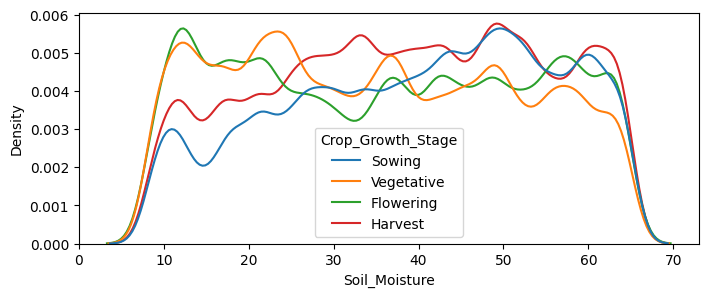

In [65]:
plt.figure(figsize=(8, 3))
sns.kdeplot(df_train, x = 'Soil_Moisture', hue = 'Crop_Growth_Stage')
plt.show()

In [67]:
y_prd_mode = df_train.groupby(X_bin + ['Mulching_Used', 'Crop_Growth_Stage'], observed = True)[y].transform(lambda x: x.mode()[0])
y_prd_mode

id
0         0
1         0
2         0
3         1
4         0
         ..
629995    1
629996    1
629997    2
629998    0
629999    0
Name: Irrigation_Need, Length: 630000, dtype: int64

In [69]:
pd.crosstab(index = df_train[y], columns = y_prd_mode)

Irrigation_Need,0,1,2
Irrigation_Need,,,
0,368332,1585,0
1,5269,232330,1475
2,0,1849,19160


In [70]:
from sklearn.metrics import recall_score
recall_score(df_train[y], y_prd_mode, average = 'macro')

np.float64(0.9598321718068877)

- 이 Article으로 구분했을 때의 balanced accuracy는 0.96 정도 된다. 

In [95]:
s_rep_target = 1 / df_train[y].value_counts(normalize = True)
s_rep_target

Irrigation_Need
0     1.703085
1     2.635167
2    29.987148
Name: proportion, dtype: float64

In [103]:
y_prd_weight = df_train.groupby(X_bin + ['Mulching_Used', 'Crop_Growth_Stage'], observed = True)[y].transform(
    lambda x: (pd.Series(x.value_counts(normalize=True), index = s_rep_target.index).fillna(0)*s_rep_target).idxmax()
)

In [104]:
recall_score(df_train[y], y_prd_weight, average = 'macro')

np.float64(0.9634790242625418)

- y 클래스 비율의 역수를 주면 0.963 가지 올라간다.

In [121]:
df_ce_grad = (df_train.groupby(X_bin + ['Mulching_Used', 'Crop_Growth_Stage', y], observed = True).size().unstack().fillna(0) * s_rep_target).apply(
    lambda x: x / x.sum() - (x.index == x.idxmax()), axis = 1
).fillna(0)
df_ce_grad

Irrigation_Need                                                          0  \
Soil_25 Temp_30 Rain_300 Wind_10 Mulching_Used Crop_Growth_Stage             
0       0       0        0       No            Sowing            -0.000259   
                                               Vegetative        -0.070164   
                                               Flowering         -0.057529   
                                               Harvest            0.000000   
                                 Yes           Sowing             0.000000   
...                                                                    ...   
1       1       1        1       No            Harvest            0.000000   
                                 Yes           Sowing             0.000000   
                                               Vegetative         0.000000   
                                               Flowering          0.000000   
                                               Harvest            0.000000   

Irrigation_Need                                                          1  \
Soil_25 Temp_30 Rain_300 Wind_10 Mulching_Used Crop_Growth_Stage             
0       0       0        0       No            Sowing             0.000259   
                                               Vegetative         0.070164   
                                               Flowering          0.057529   
                                               Harvest            0.000000   
                                 Yes           Sowing             0.000000   
...                                                                    ...   
1       1       1        1       No            Harvest            0.022882   
                                 Yes           Sowing             0.340170   
                                               Vegetative         0.007489   
                                               Flowering          0.004317   
                                               Harvest            0.360990   

Irrigation_Need                                                          2  
Soil_25 Temp_30 Rain_300 Wind_10 Mulching_Used Crop_Growth_Stage            
0       0       0        0       No            Sowing             0.000000  
                                               Vegetative         0.000000  
                                               Flowering          0.000000  
                                               Harvest            0.000000  
                                 Yes           Sowing             0.000000  
...                                                                    ...  
1       1       1        1       No            Harvest           -0.022882  
                                 Yes           Sowing            -0.340170  
                                               Vegetative        -0.007489  
                                               Flowering         -0.004317  
                                               Harvest           -0.360990  

[128 rows x 3 columns]

In [127]:
df_train_gd = df_train.join(
    df_ce_grad[[0, 1]].rename(columns = lambda x: 'loss_{}'.format(x)), on = X_bin + ['Mulching_Used', 'Crop_Growth_Stage']
)
df_train_gd.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,...,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need,Soil_25,Temp_30,Rain_300,Wind_10,loss_0,loss_1
id,,,,,,,,,,,,,,,,,,,,,
0,Loamy,4.92,32.580002,1.01,3.05,15.010000,50.610001,725.989990,5.90,16.790001,...,No,112.160004,East,0,0,0,0,1,-0.005484,0.005484
1,Clay,7.08,56.610001,0.44,2.00,22.920000,67.860001,985.659973,6.98,3.390000,...,Yes,47.160000,South,0,0,0,0,0,-0.002966,0.002966
2,Clay,5.69,27.709999,0.81,2.83,26.969999,92.220001,2201.699951,6.05,3.850000,...,Yes,110.379997,North,0,0,0,0,0,-0.002966,0.002966
3,Sandy,5.65,13.320000,1.33,0.87,13.320000,61.570000,1357.329956,9.12,2.310000,...,Yes,53.849998,South,1,1,0,0,0,0.001458,-0.001458
4,Clay,7.96,59.139999,0.38,0.96,20.219999,91.110001,1538.199951,6.95,13.940000,...,No,93.190002,South,0,0,0,0,1,-0.005484,0.005484


In [135]:
from scipy.stats import pearsonr
for i in X_num:
    print(i, pearsonr(df_train_gd[i], df_train_gd['loss_0']).pvalue, pearsonr(df_train_gd[i], df_train_gd['loss_1']).pvalue)

Electrical_Conductivity 0.04193404543659403 6.637088415526703e-11
Field_Area_hectare 9.115089085627625e-11 2.4322743575657146e-13
Humidity 1.6230386422290933e-26 2.7421124995913125e-22
Organic_Carbon 0.4598702209029488 4.55385155410721e-11
Previous_Irrigation_mm 4.182879388417413e-23 0.04195187894745239
Rainfall_mm 8.392313845071765e-180 1.5966435787440033e-07
Soil_Moisture 3.5276387722020176e-63 0.0
Soil_pH 0.434690913931772 0.010797826484345411
Sunlight_Hours 0.0796798923573787 0.26375331983867506
Temperature_C 0.0 0.0
Wind_Speed_kmh 0.0 0.0


## Ordinal Regression vs Multi-classs Classification

In [4]:
import xgboost as xgb
from sklearn.model_selection import cross_val_score, cross_validate, cross_val_predict, StratifiedKFold

def ordinal_obj(y, preds):
    # preds: f(x)
    theta1, theta2 = 0.0, 1.0
    w = np.where(y == 0, 1,
        np.where(y == 1, 1, 5))
    def sigmoid(x):
        return 1 / (1 + np.exp(-x))
    
    # y > 0, y > 1
    t1 = (y > 0).astype(float)
    t2 = (y > 1).astype(float)
    
    p1 = sigmoid(preds - theta1)
    p2 = sigmoid(preds - theta2)
    
    g = (p1 - t1) + (p2 - t2)
    h = p1 * (1 - p1) + p2 * (1 - p2)
    
    return g * w, h * w
skf = StratifiedKFold(5, random_state = 123, shuffle = True)

In [18]:
result = cross_validate(
    xgb.XGBClassifier(random_state = 123, enable_categorical = True), df_train[X_all], df_train[y], cv = skf, scoring = 'recall_macro', return_train_score = True
)
result['test_score'].mean(), result['train_score'].mean()

(np.float64(0.9618857249589903), np.float64(0.9737837186549714))

In [216]:
cv_prds = cross_val_predict(
    xgb.XGBRegressor(random_state = 123, enable_categorical = True, objective=ordinal_obj), df_train[X_all], df_train[y], cv = skf
)
scores = recall_score(
    df_train[y], (cv_prds > 0).astype('int') + (cv_prds > 1).astype('int'), average = 'macro'
)
np.mean(scores)

np.float64(0.9660454987272336)

In [285]:
import lightgbm as lgb

theta1, theta2 = 0.0, 1.0
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def ordinal_obj(y, preds):
    # preds: f(x)
    w = np.where(y == 0, 1, np.where(y == 1, 1.2, 5))
    
    # y > 0, y > 1
    t1 = (y > 0).astype(float)
    t2 = (y > 1).astype(float)
    
    p1 = sigmoid(preds - theta1)
    p2 = sigmoid(preds - theta2)
    
    g = (p1 - t1) + (p2 - t2)
    h = p1 * (1 - p1) + p2 * (1 - p2)
    
    return g * w, h * w

cv_prds = cross_val_predict(
    lgb.LGBMRegressor(random_state = 123, verbose = -1, objective=ordinal_obj), df_train[X_all], df_train[y], cv = skf
)
scores = recall_score(
    df_train[y], (cv_prds > theta1).astype('int') + (cv_prds > theta2).astype('int'), average = 'macro'
)
np.mean(scores)

np.float64(0.966047450465891)

In [267]:
cv_prds = (cv_prds > 0).astype('int') + (cv_prds > 1).astype('int')
scores = [
    recall_score(df_train.iloc[valid_idx][y], cv_prds[valid_idx], average = 'macro')
    for _, valid_idx in skf.split(df_train[X_all], df_train[y])
]
np.mean(scores), np.std(scores)

(np.float64(0.9660474548809278), np.float64(0.0010860845720993995))

In [242]:
scores = cross_val_score(
    lgb.LGBMClassifier(random_state = 123, verbose = -1), df_train[X_all], df_train[y], scoring = 'recall_macro', cv = skf
)
np.mean(scores)

np.float64(0.9612163264170194)

In [53]:
scores = cross_val_score(
    lgb.LGBMClassifier(random_state = 123, verbose = -1, class_weight = 'balanced'), df_train[X_all], df_train[y], scoring = 'recall_macro', cv = skf
)
np.mean(scores)

np.float64(0.9695662944634276)

- LGBM에서는 떨어진다. class weight를 조절하는 것보다는 떨어지기도 한다.

- 우선적으로 Class의 빈도에 따른 가중치를 조정하는 방향으로 학습

- XGBClassifier는 클래스 단위의 가중치를 설정하는 기능 없다. 표본단위의 설정은 가능하다. 기능 구현후 테스트해보자

In [6]:
from sklearn.metrics import balanced_accuracy_score
s_weight = df_train[y].value_counts().pipe(
    lambda x: x.max() / x
)
s_weight

Irrigation_Need
0     1.000000
1     1.547291
2    17.607549
Name: count, dtype: float64

In [7]:
df_train['sample_weight'] = df_train[y].map(s_weight)

In [9]:
if not os.path.exists('exp/xgb_weight'):
    e_xgb_weight = Experimenter.create(df_train, 'exp/xgb_weight', sp = skf, splitter_params={'y': y})
    e_xgb_weight.set_grp('clf', method = 'predict', role = 'head', edges = {'y': [(None, y)], 'sample_weight': [(None, 'sample_weight')]})
    e_xgb_weight.add_collector(
        MetricCollector(
            'bAcc', Connector(edges = {'y': [(None, y)]}, role = 'head'), slice(-1, None), balanced_accuracy_score, include_train = True
        )
    )
    e_xgb_weight.set_node('xgb', grp='clf', processor=xgb.XGBClassifier, edges={'X': [(None, X_all)]}, params={'random_state': 123, 'enable_categorical': True})
    e_xgb_weight.set_node('lgb', grp='clf', processor=lgb.LGBMClassifier, edges={'X': [(None, X_all)]}, params={'random_state': 123, 'verbose': -1})
    e_xgb_weight.exp(finalize=True)
else:
    e_xgb_weight = Experimenter.load('exp/xgb_weight', df_train)
e_xgb_weight.get_collector('bAcc').get_metrics_agg()[0]

Loaded: 2 node(s), 1 group(s), 5 fold(s)


,test,train
lgb,0.969615,0.978908
xgb,0.969559,0.989462


- lgb와 마찬가지로 class_weight를 사용한 효과를 볼 수 있다.

- Ordinal Regression은 효과가 있었지만, class_weight 조정을 통해 성능 향상에서의 weight를 산정하기 어려고 Classifier 만큼의 효과를 얻기 힘들었다.

## ML을 통한 속성의 중요도 파악

In [78]:
from mllabs import ColSelector
from mllabs.adapter import XGBoostAdapter, LightGBMAdapter, CatBoostAdapter
from mllabs.nn import NNClassifier
from mllabs import ProgressSessionLogger, TqdmProgressSession
from mllabs.col import ohe_drop_first
from mllabs.collector import SHAPCollector
from mllabs.filter import RandomFilter

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import catboost as cb

if not os.path.exists('exp/imp'):
    sss1 = StratifiedShuffleSplit(n_splits = 1, random_state = 123, train_size = 0.8)
    sss2 = StratifiedShuffleSplit(n_splits = 1, random_state = 123, train_size = 0.9)
    e_imp = Experimenter.create(
        df_train, 'exp/imp', sp = sss1, sp_v = sss2, splitter_params={'y': y}, 
        logger=ProgressSessionLogger(level=['info', 'progress'], session_cls=TqdmProgressSession))
    e_imp.set_grp('clf', method = 'predict', role = 'head', edges = {'y': [(None, y)], 'sample_weight': [(None, 'sample_weight')]})
    e_imp.set_grp(
        'xgb', parent = 'clf', processor=xgb.XGBClassifier, adapter=XGBoostAdapter(eval_mode='both'), 
        params={'random_state': 123, 'n_estimators': 10000, 'enable_categorical': True, 'early_stopping_rounds': 50, 'eval_metric': 'mlogloss'})
    e_imp.add_collector(ModelAttrCollector('xgb_evals_results', Connector(processor=xgb.XGBClassifier), 'evals_result'))
    e_imp.set_grp(
        'lgb', parent = 'clf', processor=lgb.LGBMClassifier, adapter=LightGBMAdapter(eval_mode='both'), 
        params={'random_state': 123, 'n_estimators': 10000, 'verbose': -1, 'early_stopping': {'stopping_rounds': 50, 'first_metric_only': True},'eval_metric': 'multi_logloss'})
    e_imp.add_collector(
        ModelAttrCollector('lgb_evals_results', Connector(processor=lgb.LGBMClassifier), 'evals_result'))
    e_imp.set_grp(
        'cb', parent = 'clf', processor=cb.CatBoostClassifier, adapter=CatBoostAdapter(eval_mode='valid'),
        params={'early_stopping_rounds': 50, 'eval_metric': 'AUC', 'verbose': 0, 'random_state': 123, 'cat_features': ColSelector(col_type='category')})
    e_imp.add_collector(
        ModelAttrCollector('cb_evals_results', Connector('_base$', processor=cb.CatBoostClassifier), 'evals_result'))
    e_imp.set_grp('nn', parent = 'clf', processor = NNClassifier, params = {'metrics': ['sparse_categorical_crossentropy'], 'early_stopping': 10})
    e_imp.add_collector(
        ModelAttrCollector('nn_evals', Connector(processor=NNClassifier), result_key='evals_result'))
    e_imp.set_grp('lr', parent='clf', processor=LogisticRegression)
    e_imp.set_grp('dt', parent='clf', processor=DecisionTreeClassifier, params={'random_state': 123})
    
    y_edges = {'y': [(None, y)]}
    e_imp.add_collector(
        MetricCollector('bAcc', Connector(edges = y_edges, role = 'head'), slice(-1, None), balanced_accuracy_score, include_train = True))
    e_imp.add_collector(
        ModelAttrCollector('lgb_feature_importance', Connector(processor=lgb.LGBMClassifier, edges=y_edges), 'feature_importances'))
    e_imp.add_collector(
        ModelAttrCollector(
            'xgb_feature_importance_gain', Connector(processor=xgb.XGBClassifier, edges=y_edges), 'feature_importances', params = {'importance_type': 'gain'}))
    e_imp.add_collector(
        ModelAttrCollector(
            'xgb_feature_importance_cover', Connector(processor=xgb.XGBClassifier, edges=y_edges), 'feature_importances', params = {'importance_type': 'cover'}))
    e_imp.add_collector(
        ModelAttrCollector('cb_feature_importance', Connector(processor=cb.CatBoostClassifier, edges=y_edges), 'feature_importances_pvc'))
    e_imp.add_collector(
        ModelAttrCollector('cb_interaction', Connector(processor=cb.CatBoostClassifier, edges=y_edges), 'feature_importances_interaction'))
    e_imp.add_collector(
        ModelAttrCollector('lr_coef', Connector(processor=LogisticRegression, edges=y_edges), 'coef'))
    
    e_imp.set_grp('pre', role = 'stage', method='transform')
    e_imp.set_node('std', grp='pre', processor=StandardScaler, edges={'X': [(None, X_num)]})
    e_imp.set_node('ohe', grp='pre', processor=OneHotEncoder, edges={'X': [(None, X_cat)]}, params={'sparse_output': False})
    e_imp.build()
    
    e_imp.set_node('xgb1', grp='xgb', edges={'X': [(None, X_all)]}, params={'n_estimators': 10000})
    e_imp.set_node('lgb1', grp='lgb', edges={'X': [(None, X_all)]}, params={'n_estimators': 10000, 'gpu': None})
    e_imp.set_node('cb1', grp='cb', edges={'X': [(None, X_all)]}, params={'n_estimators': 10000})
    e_imp.set_node('nn1', grp='nn', edges={'X': [('std', None), ('ohe', ohe_drop_first)]}, params={'epochs': 200})
    e_imp.set_node('lr1', grp='lr', edges={'X': [('std', None), ('ohe', ohe_drop_first)]})
    e_imp.exp(n_jobs=2, gpu_id_list=[0])
else:
    e_imp = Experimenter.load('exp/imp', df_train, logger=ProgressSessionLogger(level=['info', 'progress'], session_cls=TqdmProgressSession))

Loaded: 7 node(s), 8 group(s), 1 fold(s)


### Balanced Accuracy Score

In [46]:
e_imp.get_collector('bAcc').get_metrics_agg()[0]

,test,train,valid
cb1,0.969736,0.978311,0.967036
lgb1,0.968272,0.991206,0.966508
lr1,0.850281,0.849519,0.850366
nn1,0.962936,0.968925,0.960099
xgb1,0.968014,0.993664,0.965650


- Logistic Regression은 Binary features를 활용한 몇몇 Feature를 가지고한 것보다 성능이 떨어짐

### Learning Curves

In [57]:
# GPU에서 수행한 CatBoost learning 진행정보를 주지 않음. 몇개의 기반 모델이 만들어 졌을까? 
e_imp.get_objs('cb1')[0].obj.tree_count_

1286

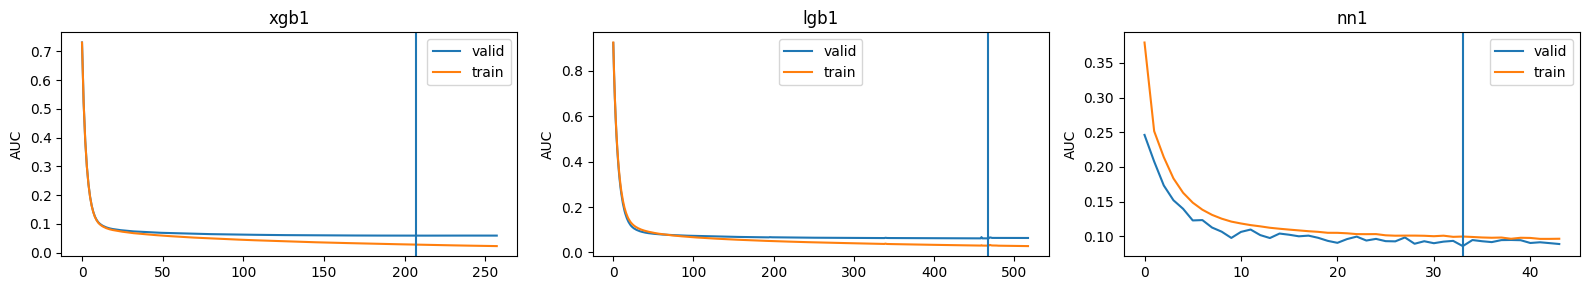

In [74]:
# Learning curves: train vs. validation AUC over boosting iterations.
# The vertical line marks the early stopping point (best validation iteration).
_, axes = plt.subplots(1, 3, figsize=(16, 3))

def plot_eval_result(name, ax, s_train, s_valid):
    sns.lineplot(s_valid, ax=ax, label='valid')
    sns.lineplot(s_train, ax=ax, label='train')
    ax.set_ylabel('AUC')
    ax.axvline(s_valid.argmin())
    ax.set_title(name)
    ax.legend()

d = e_imp.get_collector('xgb_evals_results').get_attrs()
eval_result = d['xgb1'][0][0].unstack(level=[1, 2])
plot_eval_result(
    'xgb1', axes[0],
    eval_result[('mlogloss', 'validation_0')].rename('train'),
    eval_result[('mlogloss', 'validation_1')].rename('valid')
)
d = e_imp.get_collector('lgb_evals_results').get_attrs()
eval_result = d['lgb1'][0][0].unstack(level=[1, 2])
plot_eval_result(
    'lgb1', axes[1],
    eval_result[('multi_logloss', 'training')].rename('train'),
    eval_result[('multi_logloss', 'valid_1')].rename('valid')
)
d = e_imp.get_collector('nn_evals').get_attrs()
eval_result = d['nn1'][0][0].unstack(level=[1, 2])
plot_eval_result(
    'nn1', axes[2],
    eval_result[('sparse_categorical_crossentropy', 'train')].rename('train'),
    eval_result[('sparse_categorical_crossentropy', 'valid')].rename('valid')
)
plt.tight_layout()
plt.show()

### Coefficients of LogisticRegression

In [44]:
e_imp.get_collector('lr_coef').get_attrs_agg('lr1').groupby(level = 1).apply(
    lambda x: x.abs().sum()
).sort_values(ascending = False).iloc[:20]

ohe__Crop_Growth_Stage_Sowing        10.089531
ohe__Crop_Growth_Stage_Harvest        9.574764
ohe__Mulching_Used_Yes                5.722053
std__Soil_Moisture                    4.526913
intercept                             4.387091
std__Temperature_C                    2.870899
std__Wind_Speed_kmh                   2.509480
std__Rainfall_mm                      1.605653
ohe__Water_Source_River               0.847391
ohe__Crop_Type_Rice                   0.636892
ohe__Irrigation_Type_Drip             0.621630
ohe__Water_Source_Reservoir           0.562436
ohe__Crop_Type_Potato                 0.502135
ohe__Water_Source_Rainwater           0.472143
ohe__Irrigation_Type_Rainfed          0.395907
ohe__Soil_Type_Silt                   0.364503
ohe__Soil_Type_Loamy                  0.291360
ohe__Irrigation_Type_Sprinkler        0.241958
ohe__Crop_Type_Maize                  0.221815
ohe__Crop_Growth_Stage_Vegetative     0.205088
dtype: float64

In [18]:
d = e_imp.get_node_train_data('xgb1')

In [79]:
shap_col = SHAPCollector(
    'shap',
    Connector(processor=xgb.XGBClassifier),
    data_filter=RandomFilter(frac=0.1, random_state=1)
)
e_imp.collect(shap_col)

In [35]:
pd.concat([
    e_imp.collectors['lgb_feature_importance'].get_attrs_agg('lgb1').pipe(
        lambda x: x / x.sum()
    ).rename('lgb'),
    e_imp.collectors['xgb_feature_importance_gain'].get_attrs_agg('xgb1').pipe(
        lambda x: x / x.sum()
    ).rename('xgb_gain'),
    e_imp.collectors['xgb_feature_importance_cover'].get_attrs_agg('xgb1').pipe(
        lambda x: x / x.sum()
    ).rename('xgb_cover'),
    e_imp.collectors['cb_feature_importance'].get_attrs_agg('cb1').pipe(
        lambda x: x / x.sum()
    ).rename('cb'),
    shap_col.get_feature_importance_agg('xgb1').pipe(lambda x: x / x.sum()).rename('xgb_shap')
], axis=1).pipe(
    lambda x: x.iloc[np.argsort(-x.sum(axis=1))]
)

,lgb,xgb_gain,xgb_cover,cb,xgb_shap
Soil_Moisture,0.102849,0.214121,0.099034,0.246261,0.242036
Crop_Growth_Stage,0.023813,0.223518,0.133475,0.237035,0.203889
Mulching_Used,0.024976,0.291083,0.173068,0.103153,0.097994
Temperature_C,0.100071,0.114613,0.074507,0.121091,0.107698
Wind_Speed_kmh,0.088723,0.065110,0.064786,0.107195,0.093187
Rainfall_mm,0.117189,0.044913,0.086197,0.057201,0.085357
Humidity,0.078110,0.004459,0.055269,0.022097,0.024430
Previous_Irrigation_mm,0.078799,0.004518,0.052301,0.023482,0.023970
Soil_pH,0.065123,0.003833,0.036524,0.016673,0.014124
Sunlight_Hours,0.067236,0.003737,0.032593,0.015836,0.014603


### Feature interaction

In [75]:
e_imp.get_collector('cb_interaction').get_attrs_agg('cb1').sort_values(ascending = False).iloc[:20]

feat1                    feat2            
Rainfall_mm              Temperature_C        8.396133
                         Soil_Moisture        7.637531
                         Wind_Speed_kmh       6.576665
                         Crop_Growth_Stage    6.061496
Soil_Moisture            Temperature_C        5.872829
                         Crop_Growth_Stage    5.847489
Temperature_C            Crop_Growth_Stage    5.591587
Soil_Moisture            Wind_Speed_kmh       5.544237
Temperature_C            Wind_Speed_kmh       4.945931
Wind_Speed_kmh           Crop_Growth_Stage    4.648703
Previous_Irrigation_mm   Soil_Moisture        0.426829
Humidity                 Soil_Moisture        0.400849
Soil_Moisture            Soil_pH              0.367420
Organic_Carbon           Soil_Moisture        0.313377
Soil_Moisture            Sunlight_Hours       0.309693
Humidity                 Rainfall_mm          0.304756
Electrical_Conductivity  Rainfall_mm          0.304675
Rainfall_mm           

In [105]:
e_imp.finalize(None)

Finalize 'xgb1'
Finalize 'lgb1'
Finalize 'cb1'
Finalize 'nn1'
Finalize 'lr1'


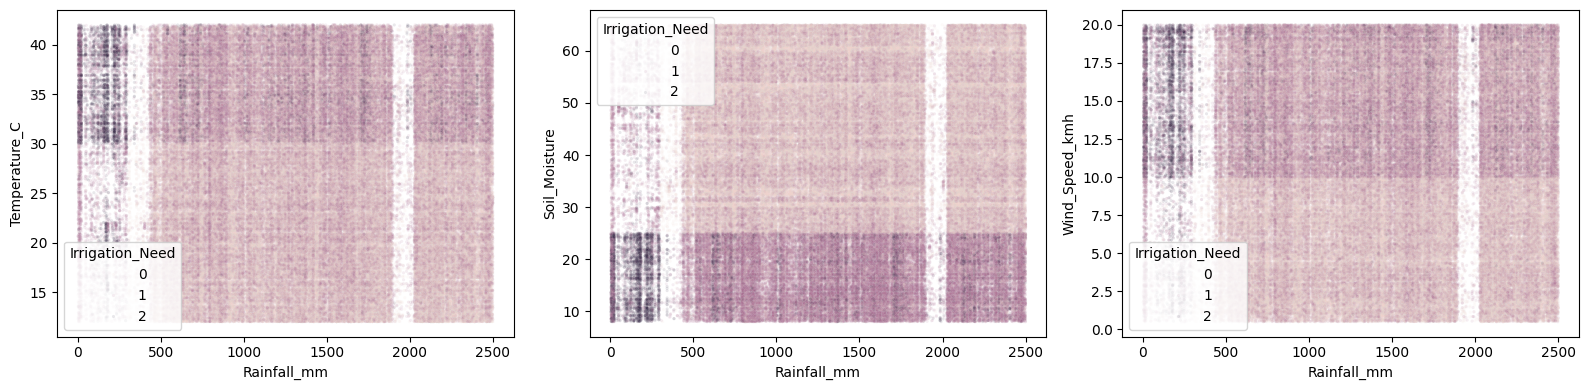

In [92]:
_, axes = plt.subplots(1, 3, figsize = (16, 4))
sns.scatterplot(df_train.sample(frac=0.5), x = 'Rainfall_mm', y = 'Temperature_C', hue = y, alpha = 0.1, s = 5, ax=axes[0])
sns.scatterplot(df_train.sample(frac=0.5), x = 'Rainfall_mm', y = 'Soil_Moisture', hue = y, alpha = 0.1, s = 5, ax=axes[1])
sns.scatterplot(df_train.sample(frac=0.5), x = 'Rainfall_mm', y = 'Wind_Speed_kmh', hue = y, alpha = 0.1, s = 5, ax=axes[2])
plt.tight_layout()
plt.show()

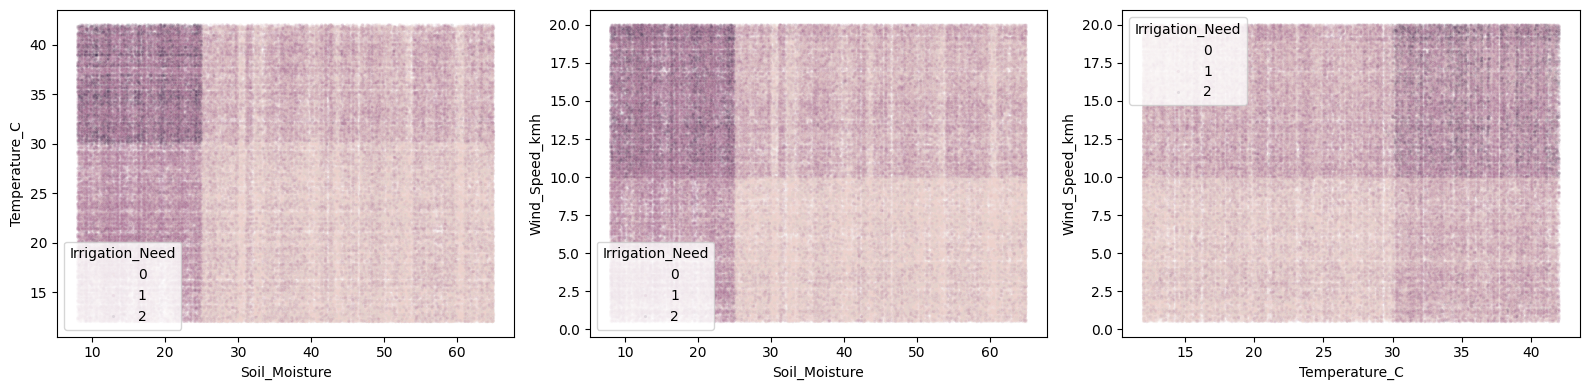

In [93]:
_, axes = plt.subplots(1, 3, figsize = (16, 4))
sns.scatterplot(df_train.sample(frac=0.5), x = 'Soil_Moisture', y = 'Temperature_C', hue = y, alpha = 0.1, s = 5, ax=axes[0])
sns.scatterplot(df_train.sample(frac=0.5), x = 'Soil_Moisture', y = 'Wind_Speed_kmh', hue = y, alpha = 0.1, s = 5, ax=axes[1])
sns.scatterplot(df_train.sample(frac=0.5), x = 'Temperature_C', y = 'Wind_Speed_kmh', hue = y, alpha = 0.1, s = 5, ax=axes[2])
plt.tight_layout()
plt.show()

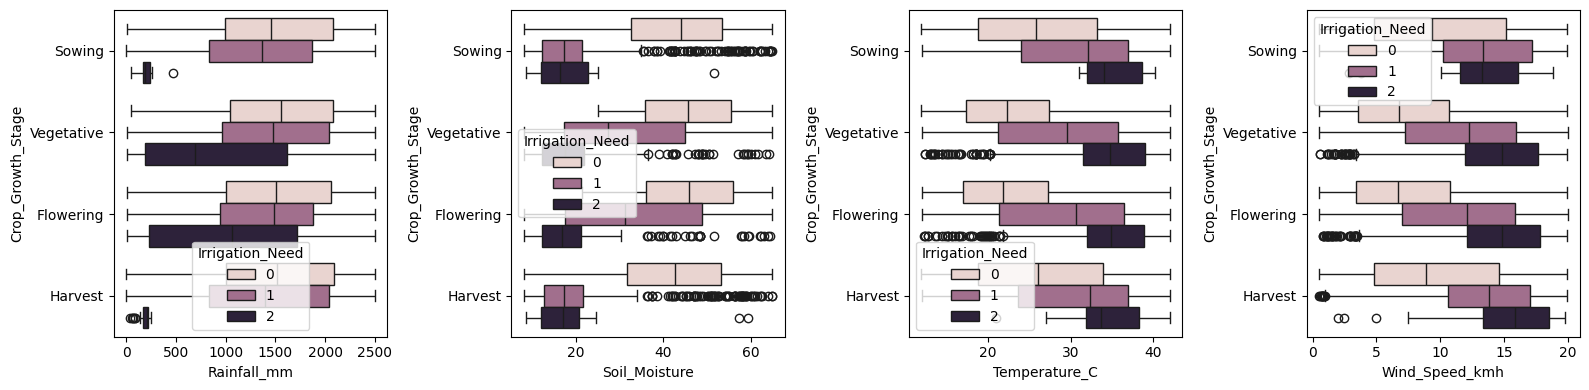

In [98]:
_, axes = plt.subplots(1, 4, figsize = (16, 4))
sns.boxplot(df_train.sample(frac=0.1), y = 'Crop_Growth_Stage', x = 'Rainfall_mm', hue = y, ax=axes[0])
sns.boxplot(df_train.sample(frac=0.1), y = 'Crop_Growth_Stage', x = 'Soil_Moisture', hue = y, ax=axes[1])
sns.boxplot(df_train.sample(frac=0.1), y = 'Crop_Growth_Stage', x = 'Temperature_C', hue = y, ax=axes[2])
sns.boxplot(df_train.sample(frac=0.1), y = 'Crop_Growth_Stage', x = 'Wind_Speed_kmh', hue = y, ax=axes[3])
plt.tight_layout()
plt.show()

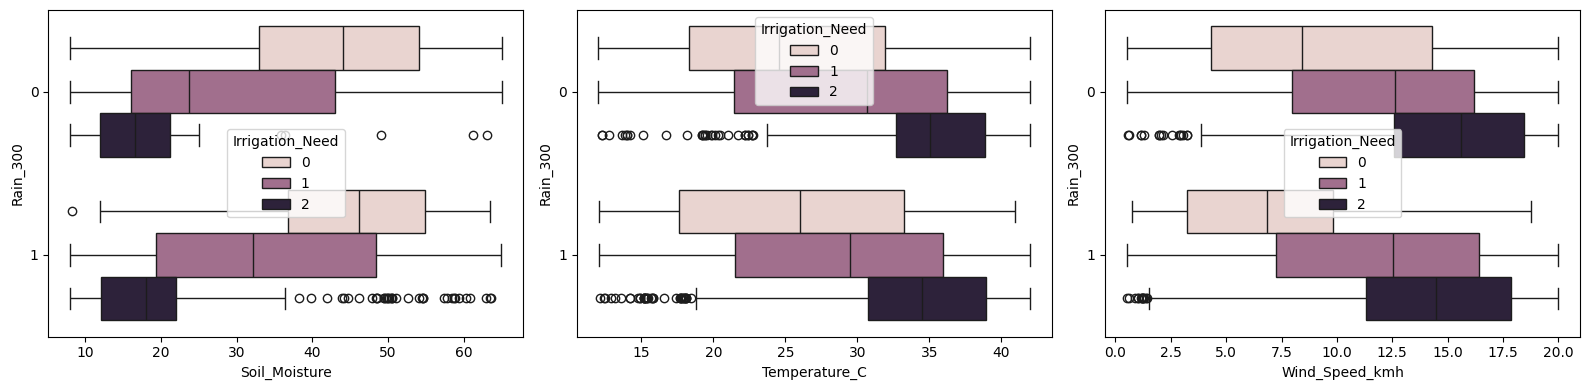

In [103]:
_, axes = plt.subplots(1, 3, figsize = (16, 4))
sns.boxplot(df_train.sample(frac=0.1).assign(Rain_300=lambda x: x['Rain_300'].astype('str')), y = 'Rain_300', x = 'Soil_Moisture', hue = y, ax=axes[0])
sns.boxplot(df_train.sample(frac=0.1).assign(Rain_300=lambda x: x['Rain_300'].astype('str')), y = 'Rain_300', x = 'Temperature_C', hue = y, ax=axes[1])
sns.boxplot(df_train.sample(frac=0.1).assign(Rain_300=lambda x: x['Rain_300'].astype('str')), y = 'Rain_300', x = 'Wind_Speed_kmh', hue = y, ax=axes[2])
plt.tight_layout()
plt.show()

In [102]:
_, axes = plt.subplots(1, 3, figsize = (16, 4))
sns.boxplot(df_train.sample(frac=0.1).assign(Rain_300=lambda x: x['Soil_25'].astype('str')), y = 'Rain_300', x = 'Soil_Moisture', hue = y, ax=axes[0])
sns.boxplot(df_train.sample(frac=0.1).assign(Rain_300=lambda x: x['Soil_25'].astype('str')), y = 'Rain_300', x = 'Temperature_C', hue = y, ax=axes[1])
sns.boxplot(df_train.sample(frac=0.1).assign(Rain_300=lambda x: x['Soil_25'].astype('str')), y = 'Rain_300', x = 'Wind_Speed_kmh', hue = y, ax=axes[2])
plt.tight_layout()
plt.show()

array([0, 1])

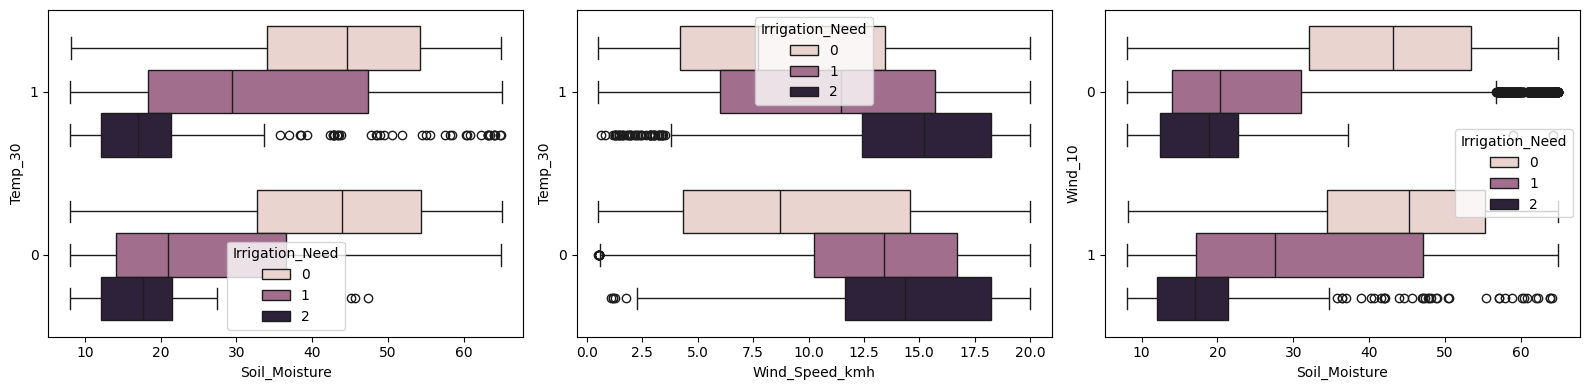

In [107]:
_, axes = plt.subplots(1, 3, figsize = (16, 4))
sns.boxplot(df_train.sample(frac=0.1).assign(Temp_30=lambda x: x['Temp_30'].astype('str')), y = 'Temp_30', x = 'Soil_Moisture', hue = y, ax=axes[0])
sns.boxplot(df_train.sample(frac=0.1).assign(Temp_30=lambda x: x['Temp_30'].astype('str')), y = 'Temp_30', x = 'Wind_Speed_kmh', hue = y, ax=axes[1])
sns.boxplot(df_train.sample(frac=0.1).assign(Wind_10=lambda x: x['Wind_10'].astype('str')), y = 'Wind_10', x = 'Soil_Moisture', hue = y, ax=axes[2])
plt.tight_layout()
plt.show()